<a href="https://colab.research.google.com/github/HamzaEric/RNN_Human_Activity_Recognition/blob/main/Notebooks/Vanilla_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from pathlib import Path
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import time

In [16]:
zip_file_path = "/content/drive/MyDrive/UCI HAR Dataset.zip"
extract_dir = "/content"


os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted files to: {extract_dir}")

Extracted files to: /content


In [17]:
BASE_DIR = Path("UCI HAR Dataset")
assert BASE_DIR.exists(), f"BASE_DIR does not exist: {BASE_DIR}"

ACTIVITY_MAP = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}
NUM_CLASSES = 6

In [18]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "total_acc_x","total_acc_y","total_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
]

def load_split(split="train", base_dir=BASE_DIR):
    """
    Returns:
        X: np.ndarray, shape (N, 128, 9)
        y: np.ndarray, shape (N,) with class indices in {0..5}
        subjects: np.ndarray, shape (N,) with subject IDs (1..30)
    """
    sig_dir = base_dir / split / "Inertial Signals"
    matrices = []
    for name in SIGNAL_NAMES:
        fpath = sig_dir / f"{name}_{split}.txt"
        arr = np.loadtxt(fpath, dtype=np.float32)  # shape: (N, 128)
        matrices.append(arr[:, :, None])           # -> (N, 128, 1)

    X = np.concatenate(matrices, axis=2)          # (N, 128, 9)
    y = np.loadtxt(base_dir / split / f"y_{split}.txt", dtype=np.int64)
    y = y - 1  # convert {1..6} -> {0..5}
    subjects = np.loadtxt(base_dir / split / f"subject_{split}.txt", dtype=np.int64)
    return X, y, subjects

X_train_np, y_train_np, subj_train = load_split("train", BASE_DIR)
X_test_np,  y_test_np,  subj_test  = load_split("test",  BASE_DIR)

print("Train X shape:", X_train_np.shape, "(N, 128, 9)")
print("Train y shape:", y_train_np.shape,  "(N,)  class indices in {0..5}")
print("Test  X shape:", X_test_np.shape)
print("Test  y shape:", y_test_np.shape)
print("Unique train labels:", np.unique(y_train_np))

Train X shape: (7352, 128, 9) (N, 128, 9)
Train y shape: (7352,) (N,)  class indices in {0..5}
Test  X shape: (2947, 128, 9)
Test  y shape: (2947,)
Unique train labels: [0 1 2 3 4 5]


In [19]:
EPS = 1e-8

train_mean = X_train_np.mean(axis=(0,1), keepdims=True)  # shape (1,1,9)
# axis(0,1) means "collapse N and T, keep channels" and get mean/std per channel. keepdims=True keeps the 3D shape for broadcasting
# axis=0 would collapse N only, giving (1, 128, 9) mean per timestep
# axis=1 would collapse T only, giving (N, 1, 9) mean per sample
# axis=2 would collapse channels only, giving (N, 128, 1) mean per sample/timestep
# We want (1,1,9) to broadcast correctly when subtracting from (N,128,9)
# So we get one mean/std per channel over the entire TRAIN set

train_std  = X_train_np.std(axis=(0,1),  keepdims=True)  # shape (1,1,9)

X_train_std = (X_train_np - train_mean) / (train_std + EPS)
X_test_std  = (X_test_np  - train_mean) / (train_std + EPS)  # use train stats!

print("Per-channel mean (train):", train_mean.reshape(-1)[:3], "... (showing first 3)")
print("Per-channel std  (train):", train_std.reshape(-1)[:3],  "... (showing first 3)")

Per-channel mean (train): [-0.00063632 -0.0002923  -0.0002753 ] ... (showing first 3)
Per-channel std  (train): [0.19478364 0.12235899 0.10680177] ... (showing first 3)


In [20]:
# Convert to PyTorch tensors

X_train_t = torch.from_numpy(X_train_std)  # (N, 128, 9), float32
y_train_t = torch.from_numpy(y_train_np)   # (N,), int64

X_test_t  = torch.from_numpy(X_test_std)
y_test_t  = torch.from_numpy(y_test_np)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Inspect one batch
xb, yb = next(iter(train_loader))
print("Batch X shape (batch-first):", tuple(xb.shape))  # (32, 128, 9)
print("Batch y shape:", tuple(yb.shape))                # (32,)

Batch X shape (batch-first): (32, 128, 9)
Batch y shape: (32,)


In [21]:
activity_map = {
    0: 'Walking',
    1: 'Walking Upstairs',
    2: 'Walking Downstairs',
    3: 'Sitting',
    4: 'Standing',
    5: 'Laying'
}

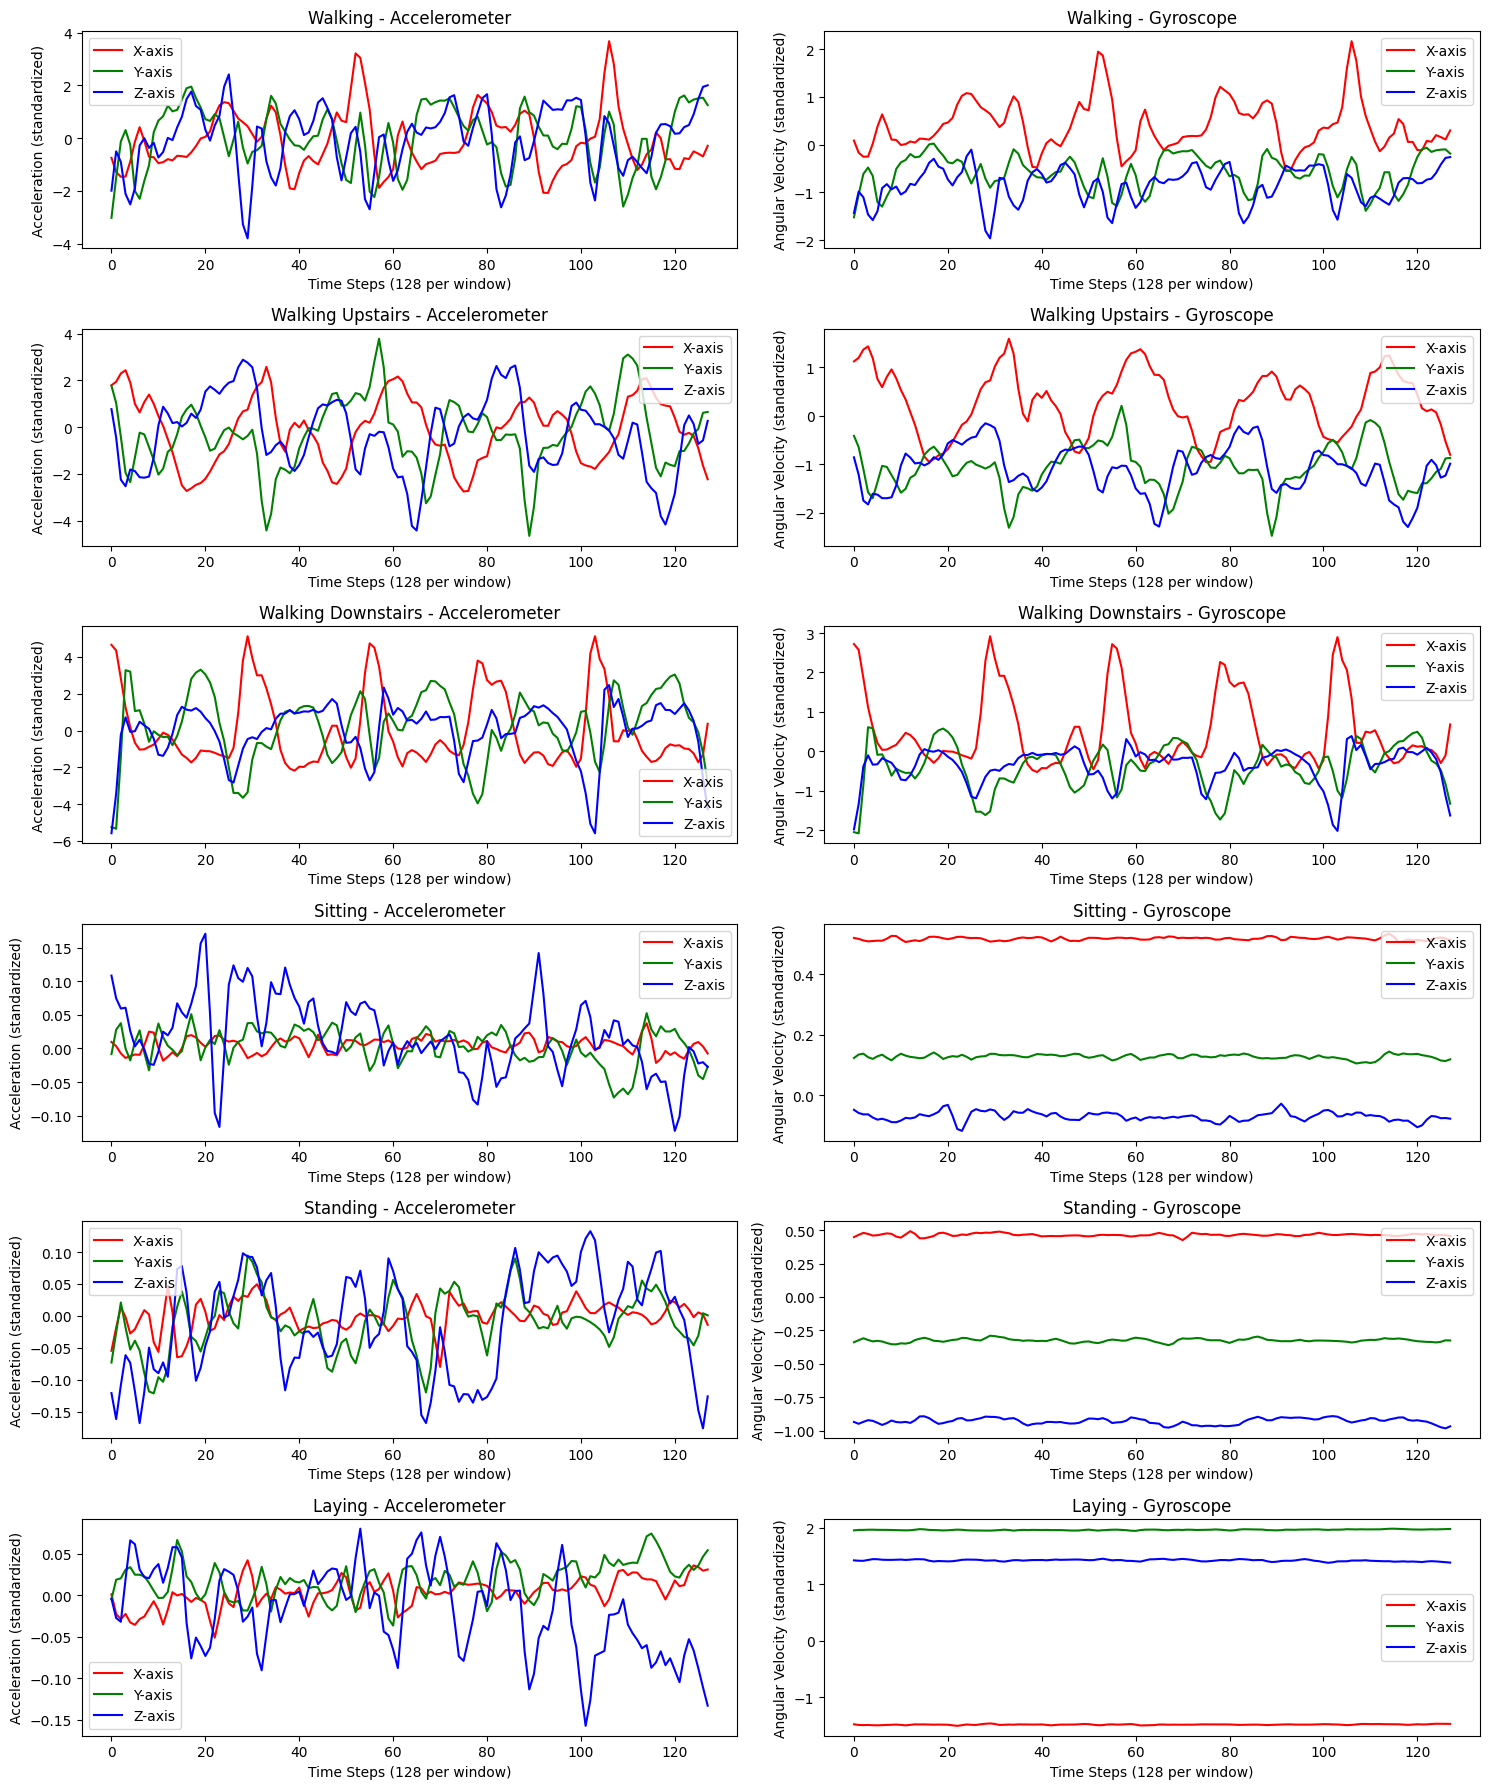

In [22]:
# Define activity_map here so the cell is self-contained
activity_map = {
    0: 'Walking',
    1: 'Walking Upstairs',
    2: 'Walking Downstairs',
    3: 'Sitting',
    4: 'Standing',
    5: 'Laying'
}

plt.figure(figsize=(15, 18))

# Randomly sample one index per class
activity_samples = {
    0: np.random.choice(np.where(y_train_np == 0)[0]),
    1: np.random.choice(np.where(y_train_np == 1)[0]),
    2: np.random.choice(np.where(y_train_np == 2)[0]),
    3: np.random.choice(np.where(y_train_np == 3)[0]),
    4: np.random.choice(np.where(y_train_np == 4)[0]),
    5: np.random.choice(np.where(y_train_np == 5)[0]),
}

for activity, index in activity_samples.items():
    # Extract accelerometer signals directly from the 3D array (channels 0, 1, 2)
    acc_x = X_train_std[index, :, 0]
    acc_y = X_train_std[index, :, 1]
    acc_z = X_train_std[index, :, 2]

    # Extract gyroscope signals directly from the 3D array (channels 3, 4, 5)
    gyro_x = X_train_std[index, :, 3]
    gyro_y = X_train_std[index, :, 4]
    gyro_z = X_train_std[index, :, 5]

    # Subplot for accelerometer
    plt.subplot(len(activity_map), 2, (activity * 2) + 1)
    plt.plot(acc_x, label='X-axis', color='r')
    plt.plot(acc_y, label='Y-axis', color='g')
    plt.plot(acc_z, label='Z-axis', color='b')

    plt.title(f"{activity_map[activity]} - Accelerometer")
    plt.xlabel("Time Steps (128 per window)")
    plt.ylabel("Acceleration (standardized)")
    plt.legend()

    # Subplot for gyroscope
    plt.subplot(len(activity_map), 2, (activity * 2) + 2)
    plt.plot(gyro_x, label='X-axis', color='r')
    plt.plot(gyro_y, label='Y-axis', color='g')
    plt.plot(gyro_z, label='Z-axis', color='b')

    plt.title(f"{activity_map[activity]} - Gyroscope")
    plt.xlabel("Time Steps (128 per window)")
    plt.ylabel("Angular Velocity (standardized)")
    plt.legend()

plt.tight_layout()
plt.show()

# Saving Preprocessed Datasets

In [23]:
np.save("X_train_std.npy", X_train_std)  # (N_train, 128, 9), float32
np.save("y_train.npy",     y_train_np)   # (N_train,), int64
np.save("X_test_std.npy",  X_test_std)   # (N_test, 128, 9)
np.save("y_test.npy",      y_test_np)    # (N_test,)


np.savez("standardization_stats.npz", train_mean=train_mean, train_std=train_std)

print("Saved: X_train_std.npy, y_train.npy, X_test_std.npy, y_test.npy, standardization_stats.npz")

Saved: X_train_std.npy, y_train.npy, X_test_std.npy, y_test.npy, standardization_stats.npz


In [25]:
# For Later Notebooks
drive_path = '/content/drive/MyDrive/HAR_Processed_Data'

os.makedirs(drive_path, exist_ok=True)

np.save(f"{drive_path}/X_train_std.npy", X_train_std)
np.save(f"{drive_path}/y_train.npy", y_train_np)
np.save(f"{drive_path}/X_test_std.npy", X_test_std)
np.save(f"{drive_path}/y_test.npy", y_test_np)

np.savez(f"{drive_path}/standardization_stats.npz", train_mean=train_mean, train_std=train_std)

print(f"Files successfully saved to your Google Drive at: {drive_path}")

Files successfully saved to your Google Drive at: /content/drive/MyDrive/HAR_Processed_Data


In [27]:
channel_order = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "total_acc_x","total_acc_y","total_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
]
def make_flat_columns():
    cols = []
    for ch in channel_order:
        for t in range(128):
            cols.append(f"{ch}_t{t:03d}")
    return cols

flat_cols = make_flat_columns()

def to_wide_df(X_std: np.ndarray, y: np.ndarray, subjects: np.ndarray) -> pd.DataFrame:
    """
    X_std: (N, 128, 9) standardized
    y:     (N,)        class indices in {0..5}
    subjects: (N,)     subject IDs
    returns a DataFrame of shape (N, 1152 + 2) with columns:
      [label, subject, body_acc_x_t000, ..., body_gyro_z_t127]
    """
    N = X_std.shape[0]
    X_flat = X_std.reshape(N, -1)  # (N, 128*9 = 1152)
    df = pd.DataFrame(X_flat, columns=flat_cols)
    df.insert(0, "subject", subjects.astype(int))
    df.insert(0, "label",   y.astype(int))  # class index {0..5}
    return df

train_df = to_wide_df(X_train_std, y_train_np, subj_train)
test_df  = to_wide_df(X_test_std,  y_test_np,  subj_test)

train_df.to_csv("har_train_standardized.csv", index=False)
test_df.to_csv("har_test_standardized.csv",   index=False)

# Save a small README-style CSV with metadata / mapping
meta = pd.DataFrame({
    "key": ["label_index_map", "channels_order", "timesteps", "standardized", "note"],
    "value": [
        "{0: WALKING, 1: WALKING_UPSTAIRS, 2: WALKING_DOWNSTAIRS, 3: SITTING, 4: STANDING, 5: LAYING}",
        str(channel_order),
        "128",
        "True (z-score per channel using train stats)",
        "Rows are one window each; columns are flattened as <channel>_t000..t127"
    ],
})
meta.to_csv("har_metadata.csv", index=False)

print("Saved: har_train_standardized.csv, har_test_standardized.csv, har_metadata.csv")

Saved: har_train_standardized.csv, har_test_standardized.csv, har_metadata.csv


In [28]:
channel_order = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "total_acc_x","total_acc_y","total_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
]

def make_flat_columns():
    cols = []
    for ch in channel_order:
        for t in range(128):
            cols.append(f"{ch}_t{t:03d}")
    return cols

flat_cols = make_flat_columns()

def to_wide_df(X_std: np.ndarray, y: np.ndarray, subjects: np.ndarray) -> pd.DataFrame:
    """
    X_std: (N, 128, 9) standardized
    y:     (N,)        class indices in {0..5}
    subjects: (N,)     subject IDs
    returns a DataFrame of shape (N, 1152 + 2) with columns:
      [label, subject, body_acc_x_t000, ..., body_gyro_z_t127]
    """
    N = X_std.shape[0]
    X_flat = X_std.reshape(N, -1)  # (N, 128*9 = 1152)
    df = pd.DataFrame(X_flat, columns=flat_cols)
    df.insert(0, "subject", subjects.astype(int))
    df.insert(0, "label",   y.astype(int))  # class index {0..5}
    return df

train_df = to_wide_df(X_train_std, y_train_np, subj_train)
test_df  = to_wide_df(X_test_std,  y_test_np,  subj_test)

# Save directly to Google Drive
train_df.to_csv(f"{drive_path}/har_train_standardized.csv", index=False)
test_df.to_csv(f"{drive_path}/har_test_standardized.csv",   index=False)

# Save a small README-style CSV with metadata / mapping
meta = pd.DataFrame({
    "key": ["label_index_map", "channels_order", "timesteps", "standardized", "note"],
    "value": [
        "{0: WALKING, 1: WALKING_UPSTAIRS, 2: WALKING_DOWNSTAIRS, 3: SITTING, 4: STANDING, 5: LAYING}",
        str(channel_order),
        "128",
        "True (z-score per channel using train stats)",
        "Rows are one window each; columns are flattened as <channel>_t000..t127"
    ],
})
meta.to_csv(f"{drive_path}/har_metadata.csv", index=False)

print(f"Saved to {drive_path}: har_train_standardized.csv, har_test_standardized.csv, har_metadata.csv")

Saved to /content/drive/MyDrive/HAR_Processed_Data: har_train_standardized.csv, har_test_standardized.csv, har_metadata.csv


In [31]:
csv_path = "/content/har_train_standardized.csv"
assert os.path.exists(csv_path), "CSV path does not exist. Please point to the saved CSV."

df = pd.read_csv(csv_path)
df_shape = df.shape
print("df_shape:", df_shape)

df_shape: (7352, 1154)


In [32]:
assert 'df' in globals(), "CT_df not found. Complete the previous task first."

df_head = df.head(5)
CT_df_first5cols = df.columns[:5].tolist()
print("CT_df_first5cols:", CT_df_first5cols)
df_head

CT_df_first5cols: ['label', 'subject', 'body_acc_x_t000', 'body_acc_x_t001', 'body_acc_x_t002']


,label,subject,body_acc_x_t000,body_acc_x_t001,body_acc_x_t002,body_acc_x_t003,body_acc_x_t004,body_acc_x_t005,body_acc_x_t006,body_acc_x_t007,...,body_gyro_z_t118,body_gyro_z_t119,body_gyro_z_t120,body_gyro_z_t121,body_gyro_z_t122,body_gyro_z_t123,body_gyro_z_t124,body_gyro_z_t125,body_gyro_z_t126,body_gyro_z_t127
0,4,1,0.004195,0.090382,0.522800,0.504396,-0.388833,0.045954,0.072998,0.175121,...,-0.022515,0.011355,0.027480,-0.018674,0.524570,-0.383995,0.023736,0.069621,0.002059,-0.006098
1,4,1,0.008882,-0.035921,-0.248912,0.518968,-0.390775,0.031962,0.040832,0.018201,...,-0.017749,-0.004941,-0.056389,-0.029231,0.516548,-0.407517,0.011505,-0.096289,-0.022576,-0.011386
2,4,1,0.021396,0.038806,-0.052801,0.529294,-0.380643,0.012915,0.063155,0.001534,...,-0.014922,0.014447,-0.042089,-0.117119,0.526618,-0.406656,-0.014006,-0.051006,-0.020981,-0.010788
3,4,1,-0.005832,-0.080853,0.012439,0.516144,-0.414897,0.024196,-0.093500,-0.031605,...,-0.044091,0.003123,-0.007706,-0.040311,0.523517,-0.414672,-0.014239,-0.018754,0.007270,-0.051244
4,4,1,0.003716,-0.029133,-0.122264,0.521627,-0.402940,-0.015813,-0.049024,-0.020407,...,-0.013904,-0.013821,0.062900,0.044488,0.513983,-0.389542,0.006482,0.037129,0.030447,-0.039880


# Vanilla RNN Classifier


---

### **4. Define the Vanilla RNN Classifier**

**Architecture (what we will build)**

We will build the simplest useful sequence classifier:

```text
Input sequence (batch, 128, 9)
│
▼
nn.RNN (hidden_size = H, num_layers = 1, batch_first = True)
│
├─ out: all hidden states (batch, 128, H)
└─ h_n: final hidden state (1, batch, H)
│
▼
Take the last hidden state h_T → (batch, H)
│
▼
Linear (H → 6 classes) → logits (batch, 6)
│
▼
CrossEntropyLoss (applies softmax internally)
```

**Key choices:**
- **Batch-first** = `True` so our inputs are `(batch, seq_len, input_size) = (B, 128, 9)`.
- **One recurrent layer**, **unidirectional**, **tanh** nonlinearity (default).
- We will start with a modest **hidden size** (e.g., `H = 32`) to keep CPU runtime low.

**Why take the *last* hidden state?**

For **sequence classification** (our HAR task), one sequence → one label.  
The **last hidden state** $h_T$ acts as a **summary** of the entire 128-timestep window.  
We map $h_T$ through a linear layer to obtain 6 logits (one per activity class).

**Loss function and outputs**

We will use **`nn.CrossEntropyLoss`**, which:
- expects **logits** of shape `(batch, num_classes)`,  
- expects **target class indices** in `{0, …, 5}`,  
- **includes softmax internally**, so we **do not** apply softmax before the loss.

(We will still use `softmax` later **only** for inspection/printing probabilities.)

**What hyperparameters matter here?**

- `hidden_size (H)`: memory capacity (e.g., 32 or 64 are good starters on CPU).
- `num_layers`: depth in the time dimension (we keep it `1` for now).
- `nonlinearity`: `"tanh"` (default) or `"relu"`; we’ll use `"tanh"` as a classic vanilla RNN.
- `bidirectional`: `False` here (we’ll keep it simple and fast).

We will **verify shapes with a dry run** on one batch before we start training.

In [33]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh"):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            batch_first=True,   # (batch, seq, input)
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        returns: logits (batch, num_classes)
        """
        # out: (batch, seq_len, hidden_size)
        # h_n: (num_layers, batch, hidden_size)
        out, h_n = self.rnn(x)
        last_hidden = h_n[-1]          # (batch, hidden_size)
        logits = self.fc(last_hidden)   # (batch, num_classes)
        return logits

# Instantiate a small model for CPU-friendly training
model = RNNClassifier(input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh")
print(model)

RNNClassifier(
  (rnn): RNN(9, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=6, bias=True)
)


In [34]:
def count_params(m: nn.Module):
    return sum(p.numel() for p in m.parameters())

total_params = count_params(model)
print(f"Total parameters: {total_params:,}")

Total parameters: 1,574


In [35]:
model.eval()
with torch.no_grad():
    xb, yb = next(iter(train_loader))     # from Section 2 DataLoader
    logits = model(xb)                    # (batch, 6)
    probs  = F.softmax(logits, dim=1)     # only for inspection
    pred   = probs.argmax(dim=1)          # predicted class indices

print("Input batch shape :", tuple(xb.shape))       # (B, 128, 9)
print("Logits shape      :", tuple(logits.shape))   # (B, 6)
print("Probs row sums    :", probs[0].sum().item()) # ~1.0
print("Targets shape     :", tuple(yb.shape))       # (B,)
print("Pred shape        :", tuple(pred.shape))     # (B,)
print("First 5 targets   :", yb[:5].tolist())
print("First 5 preds     :", pred[:5].tolist())

Input batch shape : (32, 128, 9)
Logits shape      : (32, 6)
Probs row sums    : 1.0
Targets shape     : (32,)
Pred shape        : (32,)
First 5 targets   : [4, 2, 0, 2, 1]
First 5 preds     : [1, 1, 2, 1, 1]


# Training

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# gradient clipping settings
USE_CLIP = True
MAX_NORM = 5.0

In [37]:
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """
    logits: (batch, num_classes)
    targets: (batch,)
    returns: accuracy in [0,1]
    """
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

In [38]:
# Train / Eval loops

def train_one_epoch(model, loader, optimizer, criterion, clip=USE_CLIP, max_norm=MAX_NORM):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        # Forward
        logits = model(xb)            # (batch, 6)
        loss = criterion(logits, yb)  # scalar

        # Backward
        optimizer.zero_grad()
        loss.backward()
        if clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        optimizer.step()

        # Running stats
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    avg_loss = total_loss / total_examples
    avg_acc  = total_correct / total_examples
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        logits = model(xb)
        if criterion is not None:
            total_loss += criterion(logits, yb).item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    avg_loss = (total_loss / total_examples) if criterion is not None else None
    avg_acc  = total_correct / total_examples
    return avg_loss, avg_acc

In [43]:
# Train for a few epochs (CPU-friendly)
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc":  [],
    "test_loss":  [],
    "test_acc":   [],
}

t0 = time.time()
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc*100:5.1f}% | "
          f"test_loss={te_loss:.4f} acc={te_acc*100:5.1f}%")

t1 = time.time()
print(f"Total training time ~ {t1 - t0:.1f}s (CPU)")

Epoch 01 | train_loss=0.2944 acc= 90.3% | test_loss=0.6295 acc= 82.7%
Epoch 02 | train_loss=0.2828 acc= 90.9% | test_loss=0.5682 acc= 85.6%
Epoch 03 | train_loss=0.2558 acc= 91.3% | test_loss=0.5655 acc= 85.7%
Epoch 04 | train_loss=0.2460 acc= 92.1% | test_loss=0.6722 acc= 82.4%
Epoch 05 | train_loss=0.2232 acc= 92.8% | test_loss=0.5945 acc= 84.8%
Epoch 06 | train_loss=0.2276 acc= 92.3% | test_loss=0.5313 acc= 86.5%
Epoch 07 | train_loss=0.2173 acc= 92.8% | test_loss=0.6847 acc= 84.1%
Epoch 08 | train_loss=0.2410 acc= 91.7% | test_loss=0.5984 acc= 84.2%
Epoch 09 | train_loss=0.2258 acc= 92.3% | test_loss=0.6559 acc= 83.8%
Epoch 10 | train_loss=0.2033 acc= 93.3% | test_loss=0.6376 acc= 84.8%
Total training time ~ 42.1s (CPU)


In [44]:
torch.save(model.state_dict(), "rnn_har.pth")
print("Model saved as rnn_har.pth")

Model saved as rnn_har.pth


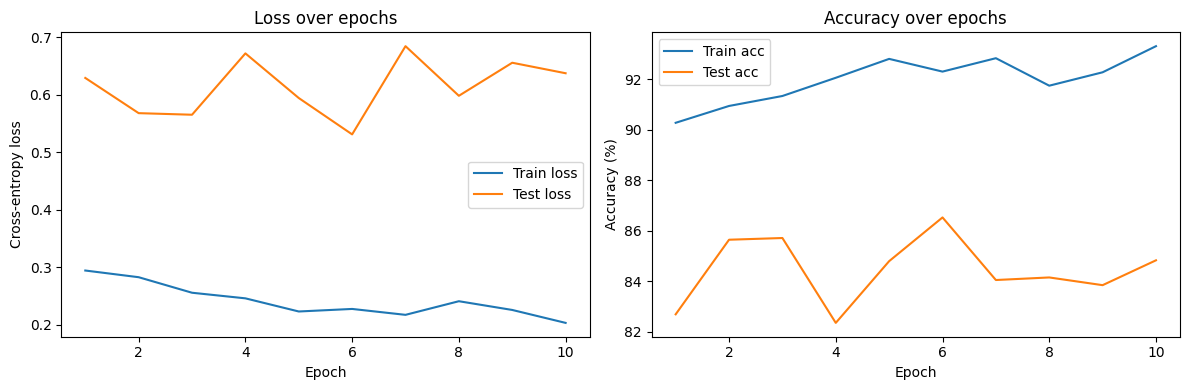

In [45]:
epochs = range(1, EPOCHS+1)

plt.figure(figsize=(12,4))
# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["test_loss"],  label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Loss over epochs")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, [a*100 for a in history["train_acc"]], label="Train acc")
plt.plot(epochs, [a*100 for a in history["test_acc"]],  label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
model.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)               # (batch, 6)
        all_logits.append(logits.cpu())
        all_targets.append(yb.cpu())

all_logits  = torch.cat(all_logits, dim=0)     # (N_test, 6)
all_targets = torch.cat(all_targets, dim=0)    # (N_test,)
all_preds   = all_logits.argmax(dim=1)         # (N_test,)

In [47]:
test_acc = (all_preds == all_targets).float().mean().item()
print(f"Test accuracy: {test_acc*100:.2f}%")

# Show a few predictions
for i in range(5):
    t = int(all_targets[i])
    p = int(all_preds[i])
    print(f"Example {i}: true={ACTIVITY_MAP[t+1]:<20s} pred={ACTIVITY_MAP[p+1]:<20s}")

Test accuracy: 84.83%
Example 0: true=STANDING             pred=STANDING            
Example 1: true=STANDING             pred=STANDING            
Example 2: true=STANDING             pred=STANDING            
Example 3: true=STANDING             pred=STANDING            
Example 4: true=STANDING             pred=STANDING            


In [48]:
from sklearn.metrics import confusion_matrix, classification_report

labels_idx = list(range(NUM_CLASSES))
labels_txt = [ACTIVITY_MAP[i+1] for i in labels_idx]

cm = confusion_matrix(all_targets.numpy(), all_preds.numpy(), labels=labels_idx)
print("Confusion Matrix (raw counts):")
print(cm)

print("\nClassification Report:")
print(classification_report(all_targets.numpy(), all_preds.numpy(), target_names=labels_txt, digits=3))

Confusion Matrix (raw counts):
[[444  20  31   0   1   0]
 [ 61 383  17   9   1   0]
 [ 48  17 355   0   0   0]
 [  1  23   0 388  79   0]
 [  2   1   0 109 420   0]
 [  0  27   0   0   0 510]]

Classification Report:
                    precision    recall  f1-score   support

           WALKING      0.799     0.895     0.844       496
  WALKING_UPSTAIRS      0.813     0.813     0.813       471
WALKING_DOWNSTAIRS      0.881     0.845     0.863       420
           SITTING      0.767     0.790     0.778       491
          STANDING      0.838     0.789     0.813       532
            LAYING      1.000     0.950     0.974       537

          accuracy                          0.848      2947
         macro avg      0.850     0.847     0.848      2947
      weighted avg      0.851     0.848     0.849      2947



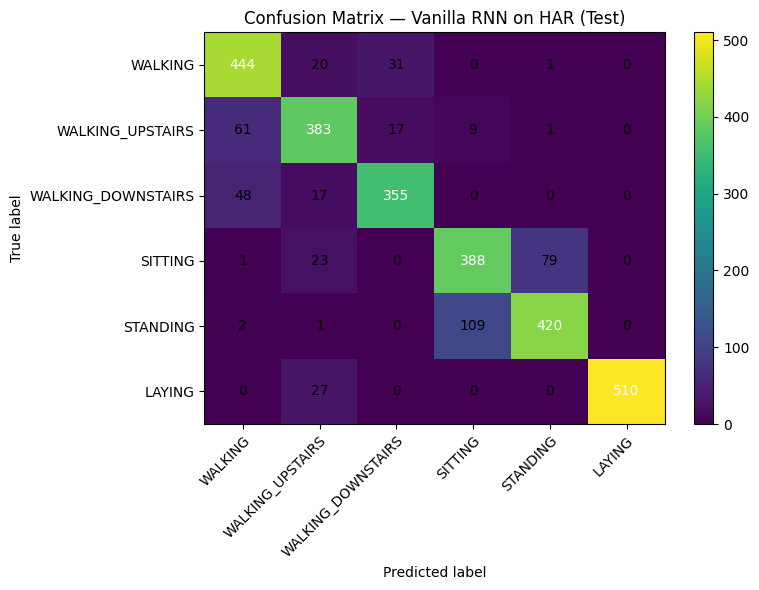

In [49]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, interpolation='nearest', aspect='auto')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=labels_txt,
    yticklabels=labels_txt,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix — Vanilla RNN on HAR (Test)"
)

# Rotate x tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate cells with counts
thresh = cm.max() / 2.0 if cm.size > 0 else 0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [50]:
cm_np = cm.astype(np.int64)
cm_offdiag = cm_np.copy()
np.fill_diagonal(cm_offdiag, 0)

# Find top-k confusions
k = 5
flat_idx = np.argsort(cm_offdiag.ravel())[::-1][:k]
rows, cols = np.unravel_index(flat_idx, cm_offdiag.shape)

print("Top confusions (true -> predicted : count):")
for r, c in zip(rows, cols):
    if cm_offdiag[r, c] > 0:
        print(f"{labels_txt[r]:<20s} -> {labels_txt[c]:<20s} : {cm_offdiag[r, c]}")

Top confusions (true -> predicted : count):
STANDING             -> SITTING              : 109
SITTING              -> STANDING             : 79
WALKING_UPSTAIRS     -> WALKING              : 61
WALKING_DOWNSTAIRS   -> WALKING              : 48
WALKING              -> WALKING_DOWNSTAIRS   : 31
